In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [3]:
base_url = "https://data.cityofchicago.org/resource/85ca-t3if.csv"

params = {
    "$select": ",".join([
        "crash_date",
        "latitude",
        "longitude",
        "injuries_total",
        "crash_hour",
        "weather_condition",
        "lighting_condition",
        "first_crash_type",
        "trafficway_type",
        "posted_speed_limit",
        "prim_contributory_cause"
    ]),
    "$where": (
        "crash_date between '2023-01-01T00:00:00' and '2023-03-31T23:59:59' "
        "AND latitude IS NOT NULL AND longitude IS NOT NULL"
    ),
    "$limit": 200000
}

r = requests.get(base_url, params=params, timeout=120)
r.raise_for_status()

df = pd.read_csv(StringIO(r.text))
df.head()

,crash_date,latitude,longitude,injuries_total,crash_hour,weather_condition,lighting_condition,first_crash_type,trafficway_type,posted_speed_limit,prim_contributory_cause
0,2023-03-31T23:52:00.000,41.888861,-87.716112,0.0,23,UNKNOWN,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,ONE-WAY,30,UNABLE TO DETERMINE
1,2023-03-31T23:45:00.000,41.924191,-87.746447,1.0,23,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,30,IMPROPER OVERTAKING/PASSING
2,2023-03-31T23:45:00.000,41.934592,-87.632078,2.0,23,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,DIVIDED - W/MEDIAN BARRIER,40,FAILING TO REDUCE SPEED TO AVOID CRASH
3,2023-03-31T23:45:00.000,41.965718,-87.647477,2.0,23,CLEAR,UNKNOWN,FIXED OBJECT,OTHER,35,NOT APPLICABLE
4,2023-03-31T23:38:00.000,41.960585,-87.762464,0.0,23,RAIN,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,30,UNABLE TO DETERMINE


In [4]:
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")
df = df.dropna(subset=["crash_date", "latitude", "longitude"]).copy()

num_cols = ["latitude", "longitude", "injuries_total", "posted_speed_limit", "crash_hour"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

cat_cols = ["weather_condition", "lighting_condition", "first_crash_type",
            "trafficway_type", "prim_contributory_cause"]
for c in cat_cols:
    df[c] = df[c].fillna("UNKNOWN").astype(str)

df["date"] = df["crash_date"].dt.floor("D")
df["injury_flag"] = (df["injuries_total"].fillna(0) > 0).astype(int)

df.shape

(24878, 13)

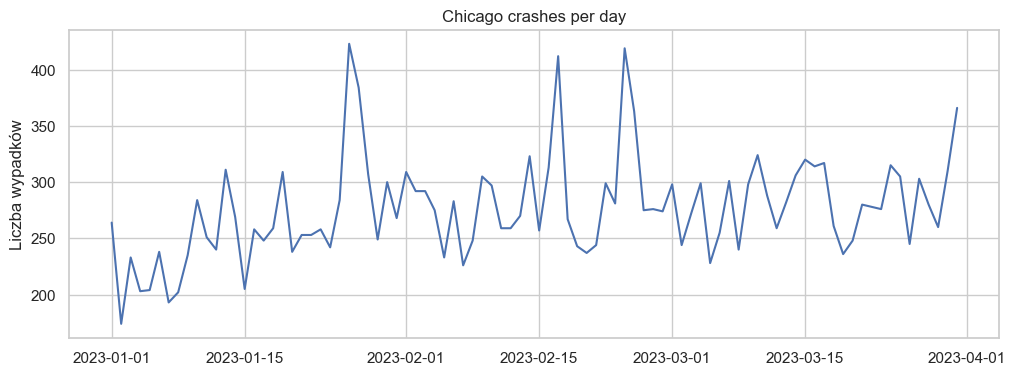

In [ ]:
daily_counts = (
    df.groupby("date")
      .size()
      .rename("n_crashes")
      .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_counts, x="date", y="n_crashes")
plt.title("Chicago crashes per day")
plt.xlabel("")
plt.ylabel("Liczba wypadków")
plt.show()

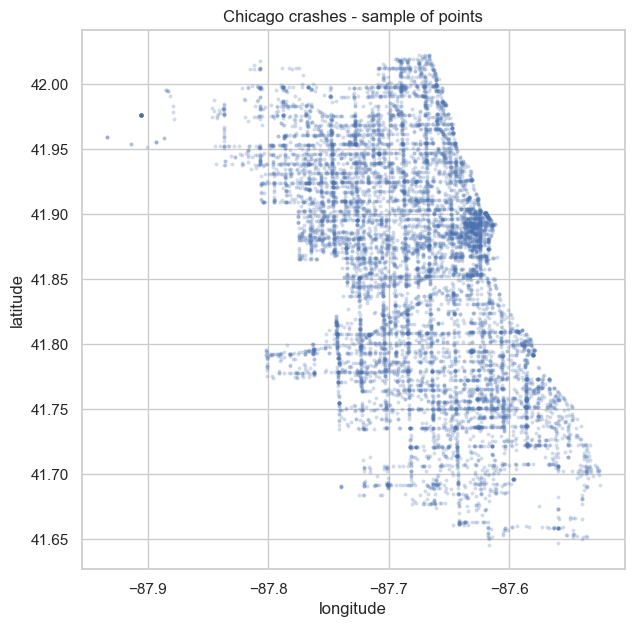

In [6]:
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="longitude",
    y="latitude",
    s=8,
    alpha=0.25,
    linewidth=0
)
plt.title("Chicago crashes - sample of points")
plt.show()

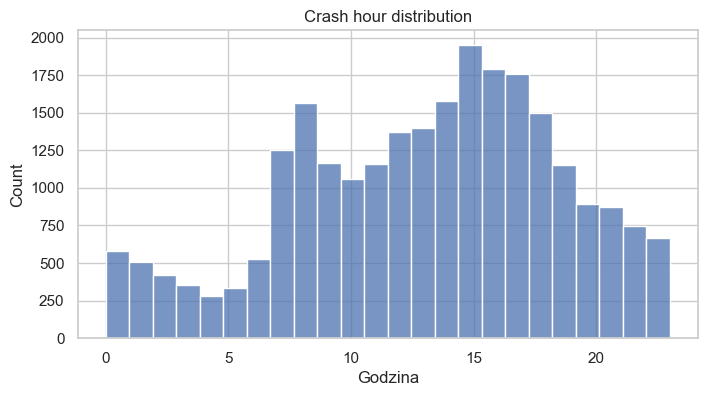

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df["crash_hour"].dropna(), bins=24)
plt.title("Crash hour distribution")
plt.xlabel("Godzina")
plt.show()